# ¿Cuándo conviene una Covered Call? Modelos de volatilidad vs. volatilidad implícita
**Finanzas Cuantitativas — FCEN/UBA · Trabajo integrador (boceto end-to-end)**

**Pregunta.** Si nuestro pronóstico de volatilidad del próximo ciclo mensual (σ̂) es *menor* que la volatilidad implícita (IV) que cobra el mercado, la call está cara y conviene venderla (Covered Call); si no, nos quedamos con el subyacente.

**Activos:** SPY (IV = VIX) y QQQ (IV = VXN). NVDA queda afuera: no hay serie histórica de IV. **Muestra:** 2007 → sep-2026 (2007 = warm-up; evaluación out-of-sample desde ene-2008).

**Reglas congeladas antes de mirar resultados** (protocolo de C8):
- Decisión con info hasta t0−1, ejecución al cierre de t0 (vencimiento mensual estándar, 3er viernes).
- Timing: vender si σ̂_ens < IV. Strike: K = S0·exp(z·σ̂_ens·√T), z = 0.5 (prob. de ejercicio según el modelo ≈ 31%).
- Precio: Black-Scholes con la IV del índice ajustada por skew (calibrada con calls de SPY de IBKR), costo = 2% de la prima.

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().resolve()
while not (ROOT / "poster").exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from poster.src.data import load_panel, load_ibkr, validate, build_cycles
from poster.src import vol_models as VM, strategy as ST, checks as CK
from poster.src.build import get_forecasts
FIG = ROOT / "poster" / "overleaf" / "figures"
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Datos

In [3]:
A = load_panel()
validate(A)

ModuleNotFoundError: No module named 'yfinance'

Panel alineado: SPY y VIX salen del Excel del profe (hoja `SPY ` con filas de dividendos mezcladas, parseadas aparte); QQQ y ^VXN vienen de yfinance; la tasa libre de riesgo es ^IRX. El retorno total se arma con Close + dividendos y se contrasta contra Adj Close más abajo.

## 2. Calibración del skew con las calls de IBKR (SPY, jun–sep 2026)
IBKR no da historia de opciones vencidas: solo hay calls vigentes (20–70 DTE). Invertimos Black-Scholes sobre el precio operado para estimar IV(K)/VIX en función de la moneyness m = ln(K/S). **Limitación:** una sola ventana de 3 meses, régimen de vol baja, precios de último trade (pueden ser viejos); para QQQ se asume el mismo skew relativo.

In [2]:
from scipy.optimize import brentq
from poster.src.strategy import black_scholes_call_price as bs
ib = load_ibkr(); s = ib[ib.symbol == "SPY"].copy()
s["date"] = pd.to_datetime(s["date"]); s["expiration"] = pd.to_datetime(s["expiration"])
s["T"] = (s.expiration - s.date).dt.days / 365.0
s["r"] = A["SPY"]["rf"].reindex(s.date).values
s = s[(s.days_to_expiration.between(20, 70)) & (s.volume >= 10)].copy()
def iv_of(row):
    f = lambda sg: bs(row.underlying_close, row.strike, row["T"], row.r, sg, 0.011) - row.close
    try: return brentq(f, 0.02, 2.0)
    except Exception: return np.nan
s["iv"] = s.apply(iv_of, axis=1)
s["m"] = np.log(s.strike / s.underlying_close); s["vix"] = A["SPY"]["iv"].reindex(s.date).values
s = s.dropna(subset=["iv", "vix"]); s["ratio"] = s.iv / s.vix
o = s[(s.m > -0.02) & (s.m < 0.06)]
b1, b0 = np.polyfit(o.m, o.ratio, 1)
print(f"IV(K)/VIX ≈ {b0:.2f} + ({b1:.2f})·m    n = {len(o)} opciones   (el pipeline usa A={ST.SKEW_A}, B={ST.SKEW_B})")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(o.m * 100, o.ratio, s=6, alpha=.25, color="#2a78d6")
xs = np.linspace(-2, 6, 50); ax.plot(xs, b0 + b1 * xs / 100, color="#eb6834", lw=2.5)
ax.set_xlabel("moneyness ln(K/S) (%)"); ax.set_ylabel("IV de la call / VIX"); ax.set_title("Skew de las calls de SPY (IBKR)")
plt.show()

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

**Kalman sobre la IV de IBKR (donde el suavizado sí sirve).** La IV diaria ATM de IBKR sale de precios esporádicos y salta; un filtro de nivel local (MLE de la razón señal/ruido) la ordena. Es el uso donde suavizar es el objetivo, a diferencia de pronosticar vol donde el filtro se evalúa out-of-sample.

In [4]:
atm = s[s.m.abs() < 0.01].groupby("date").iv.median()
y = np.log(atm.values)
th = VM.kalman_fit(y); mu, phi, q, rr = th[0], np.tanh(th[1]), np.exp(th[2]), np.exp(th[3])
_, af, _ = VM._kf(y, mu, phi, q, rr, ret_all=True)
print(f"phi={phi:.3f}   q/r={q/rr:.3f}")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(atm.index, atm.values, ".", color="#9a9990", label="IV ATM (mediana diaria, IBKR)")
ax.plot(atm.index, np.exp(af), color="#1baf7a", lw=2.5, label="Filtro de Kalman (causal)")
ax.plot(atm.index, A["SPY"]["iv"].reindex(atm.index).values, color="#eb6834", lw=1.8, label="VIX")
ax.legend(frameon=False); plt.show()

phi=0.711   q/r=2.577


## 3. Modelos de volatilidad (walk-forward, ventana expansiva)
Rolling 21d · EWMA(0.94) · GJR-GARCH(1,1)-t · HAR-RV (Corsi) · Kalman (filtro, nunca smoother) · **Ensamble** = promedio de varianzas. La IV se mide como referencia del mercado, no como modelo propio. Métricas: RMSE (en vol), **QLIKE** (sobre varianza, robusta al ruido del proxy) y R² de Mincer-Zarnowitz.

In [5]:
fcs = get_forecasts(A)
errs = {k: VM.forecast_table(f) for k, f in fcs.items()}
for k in errs:
    print(k, "— ciclos OOS:", len(fcs[k])); display(errs[k])
print("Último ajuste (SPY):", fcs["SPY"].attrs.get("garch_last"), fcs["SPY"].attrs.get("kalman_last"))

SPY — ciclos OOS: 224


,RMSE,QLIKE,sesgo,R2_MZ
modelo,,,,
Rolling21,0.0998,0.7065,0.0021,0.3831
EWMA,0.0972,0.6647,0.0058,0.3936
GJR-GARCH,0.1008,0.5342,0.0200,0.4276
HAR-RV,0.0955,0.4419,0.0285,0.4260
Kalman,0.0892,0.4295,0.0174,0.4041
Ensamble,0.0912,0.4685,0.0170,0.4396
IV,0.0962,0.4448,0.0389,0.4323


QQQ — ciclos OOS: 224


,RMSE,QLIKE,sesgo,R2_MZ
modelo,,,,
Rolling21,0.1007,0.5122,0.0024,0.3380
EWMA,0.0985,0.4618,0.0056,0.3407
GJR-GARCH,0.0978,0.4011,0.0136,0.3489
HAR-RV,0.0896,0.3342,0.0154,0.3598
Kalman,0.0873,0.3179,0.0101,0.3671
Ensamble,0.0901,0.3494,0.0114,0.3779
IV,0.0938,0.3065,0.0315,0.3962


Último ajuste (SPY): {'mu': 0.06662206208382845, 'omega': 0.024257058590013276, 'alpha[1]': 0.0, 'gamma[1]': 0.24605504883787424, 'beta[1]': 0.8576019560365284, 'nu': 5.791033891989852} {'mu': -10.162165395199642, 'phi': 0.9610623659924258, 'q': 0.08510834327226467, 'r': 0.43857450059577013, 'q_over_r': 0.1940567524027308}


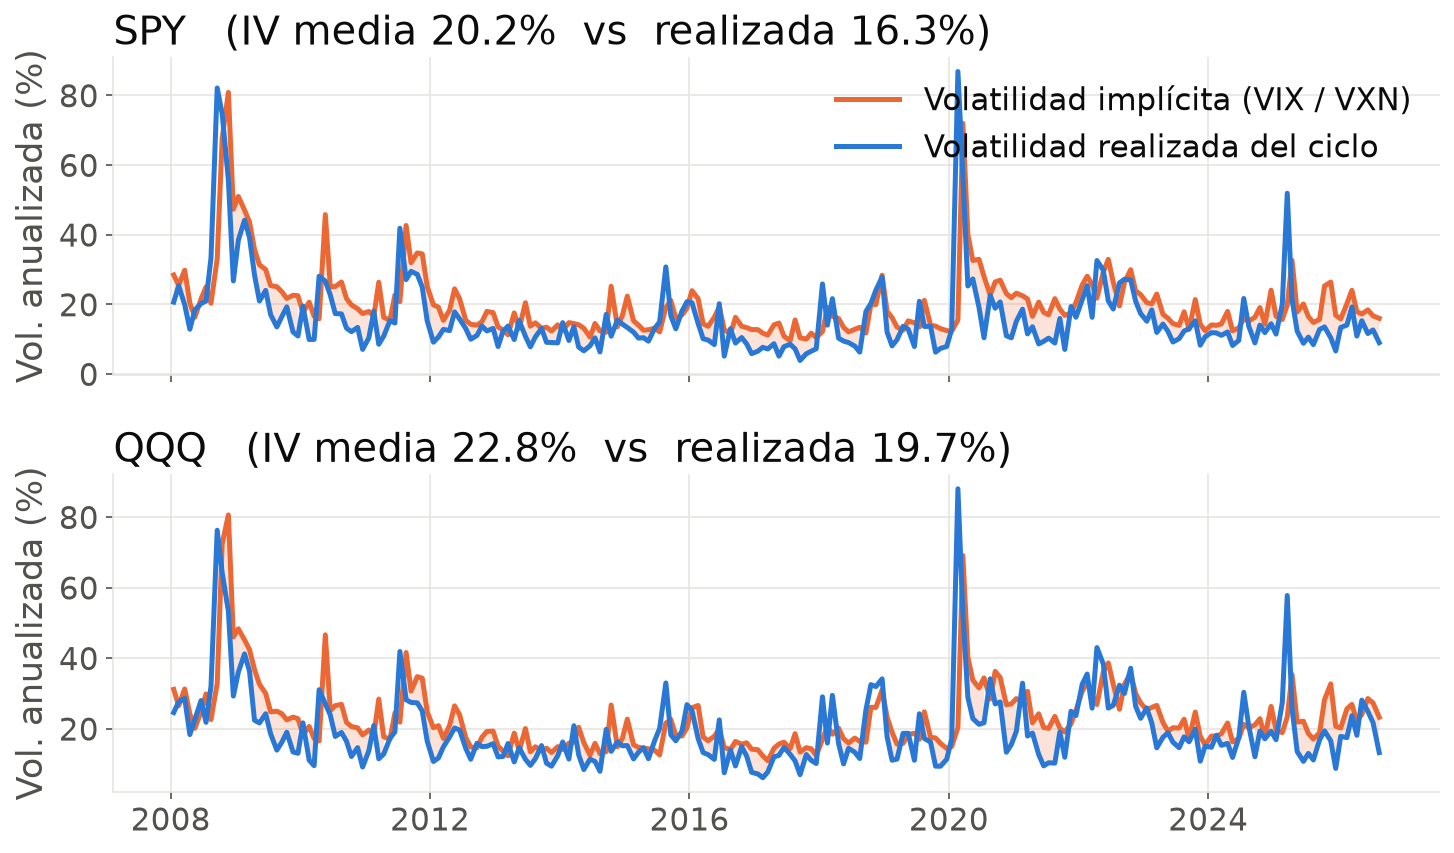

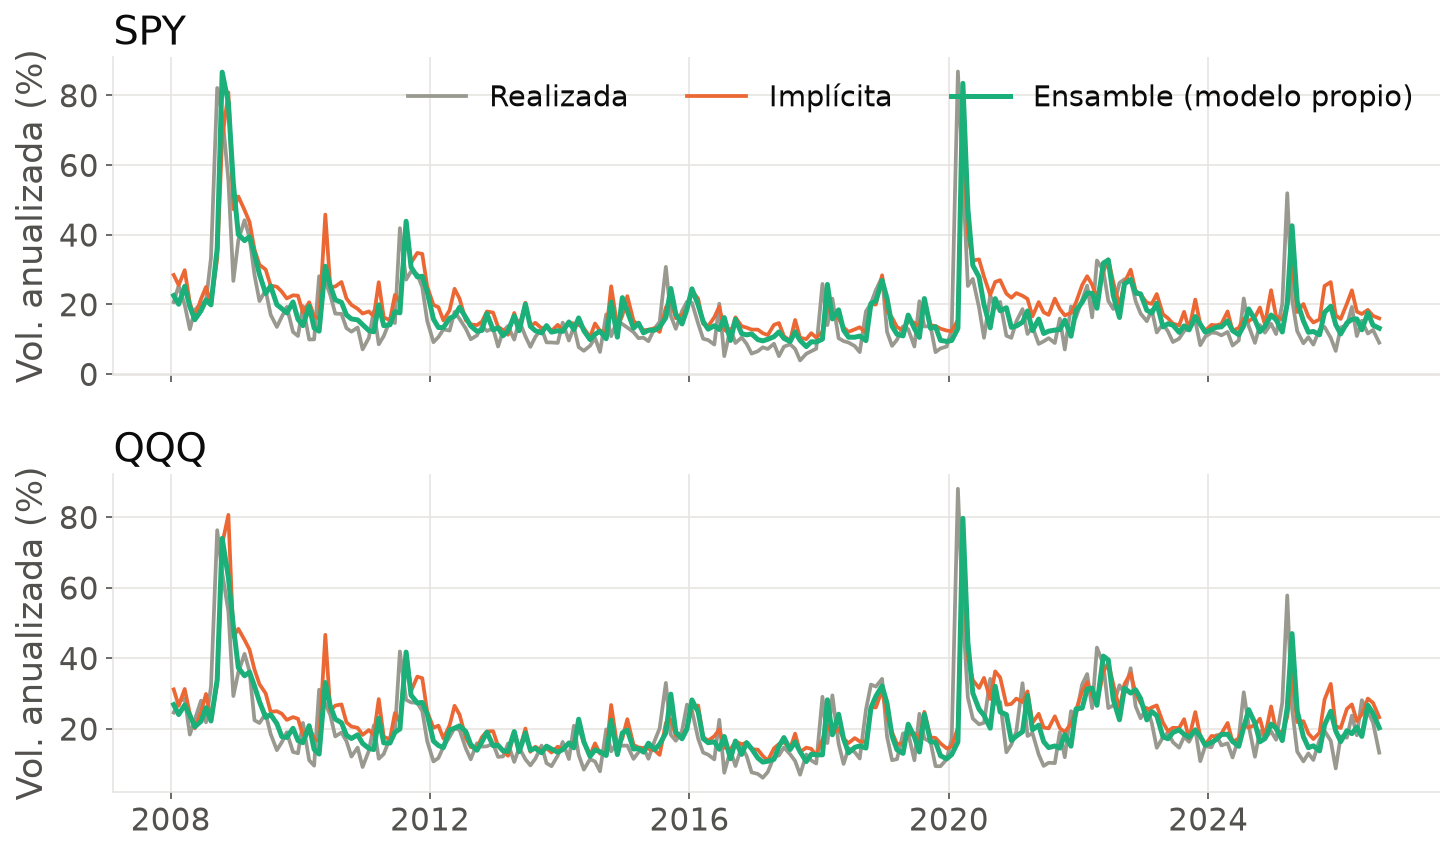

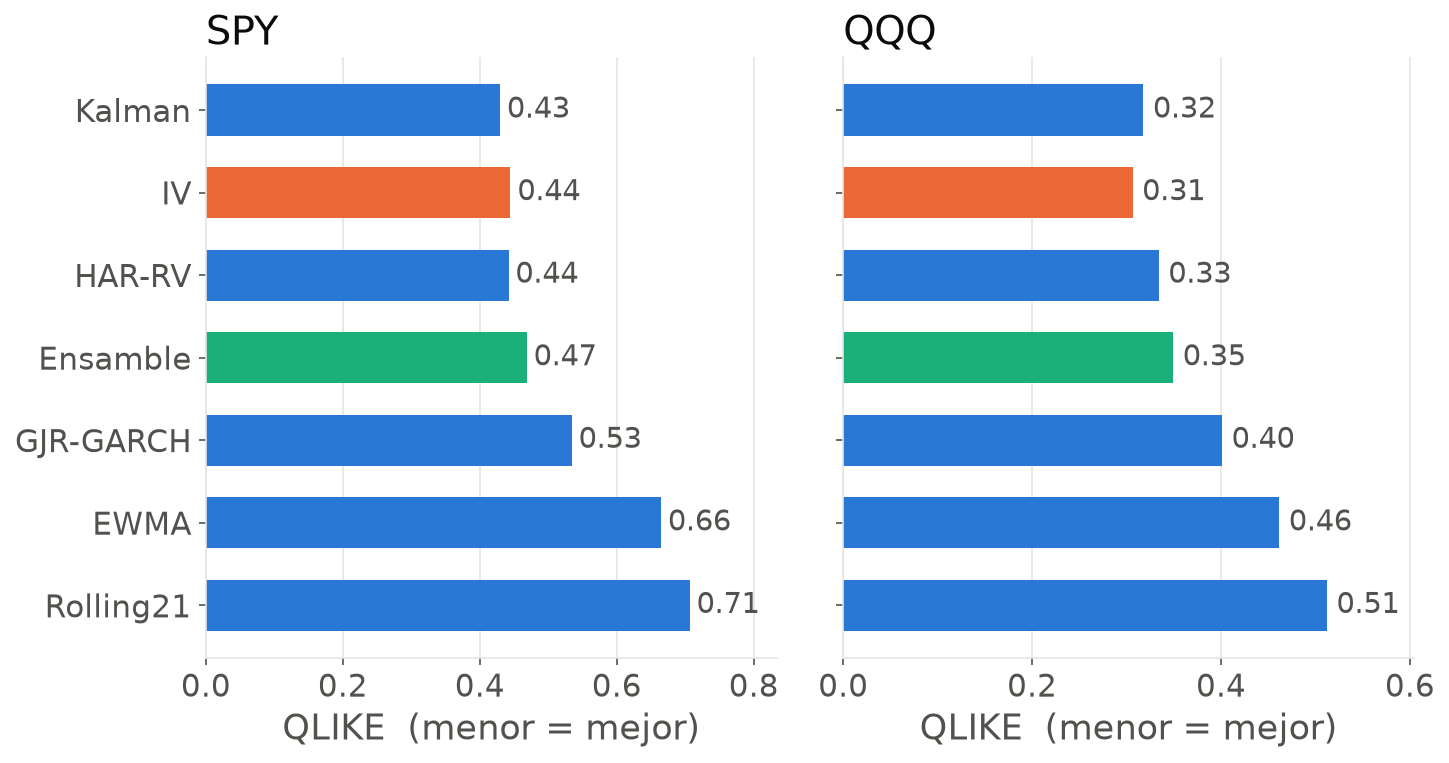

In [6]:
for n in ["fig_vrp", "fig_forecast", "fig_errors"]: display(Image(str(FIG / f"{n}.png"), width=620))

**Lectura.** (i) La IV promedia ~4 pp (SPY) y ~3 pp (QQQ) *por encima* de la volatilidad realizada: es la prima de riesgo de varianza que la Covered Call intenta cobrar. (ii) La IV es de los mejores predictores individuales (como dice la literatura) y el Kalman — estimado por MLE, con q/r ≈ 0.2, o sea que **no** suaviza de más — la iguala o la supera en QLIKE. (iii) Los modelos ingenuos (rolling, EWMA) son claramente peores. (iv) El ensamble queda entre los mejores y es más estable que cualquier modelo individual.

## 4. Estrategias

In [7]:
from poster.src.build import main as build_main
fcs, res, summ, errs, boot, extra = build_main()
for k in summ:
    print(k); display(summ[k])

SPY


,retorno_total,CAGR,vol,sharpe,maxdd,pct_vendido,n
Buy & Hold,7.1235,0.1188,0.1847,0.6330,-0.4481,0.0000,224.0000
CC estático ATM,3.0236,0.0774,0.1236,0.5631,-0.3283,1.0000,224.0000
Siempre + strike modelo,5.0909,0.1016,0.1538,0.6263,-0.4114,1.0000,224.0000
Timing modelo + ATM,3.3443,0.0819,0.1494,0.5166,-0.4107,0.8438,224.0000
CC modelo,5.6516,0.1068,0.1654,0.6212,-0.4202,0.8438,224.0000


QQQ


,retorno_total,CAGR,vol,sharpe,maxdd,pct_vendido,n
Buy & Hold,17.4946,0.1692,0.2123,0.7846,-0.4660,0.0000,224.0000
CC estático ATM,2.6760,0.0722,0.1278,0.5085,-0.3717,1.0000,224.0000
Siempre + strike modelo,4.8372,0.0991,0.1643,0.5813,-0.4554,1.0000,224.0000
Timing modelo + ATM,5.1348,0.1021,0.1676,0.5867,-0.4623,0.7411,224.0000
CC modelo,7.5317,0.1217,0.1848,0.6455,-0.4714,0.7411,224.0000


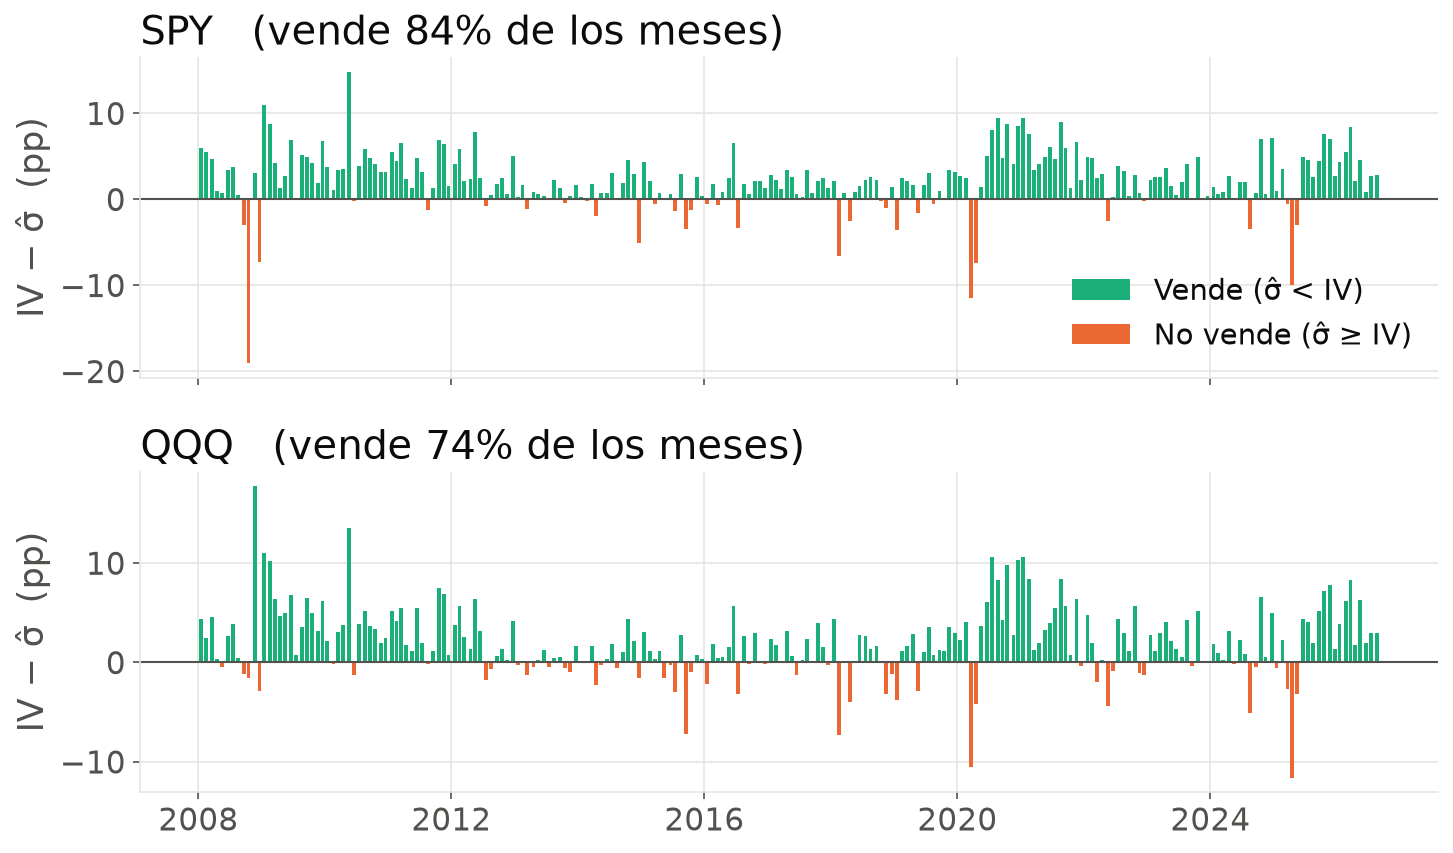

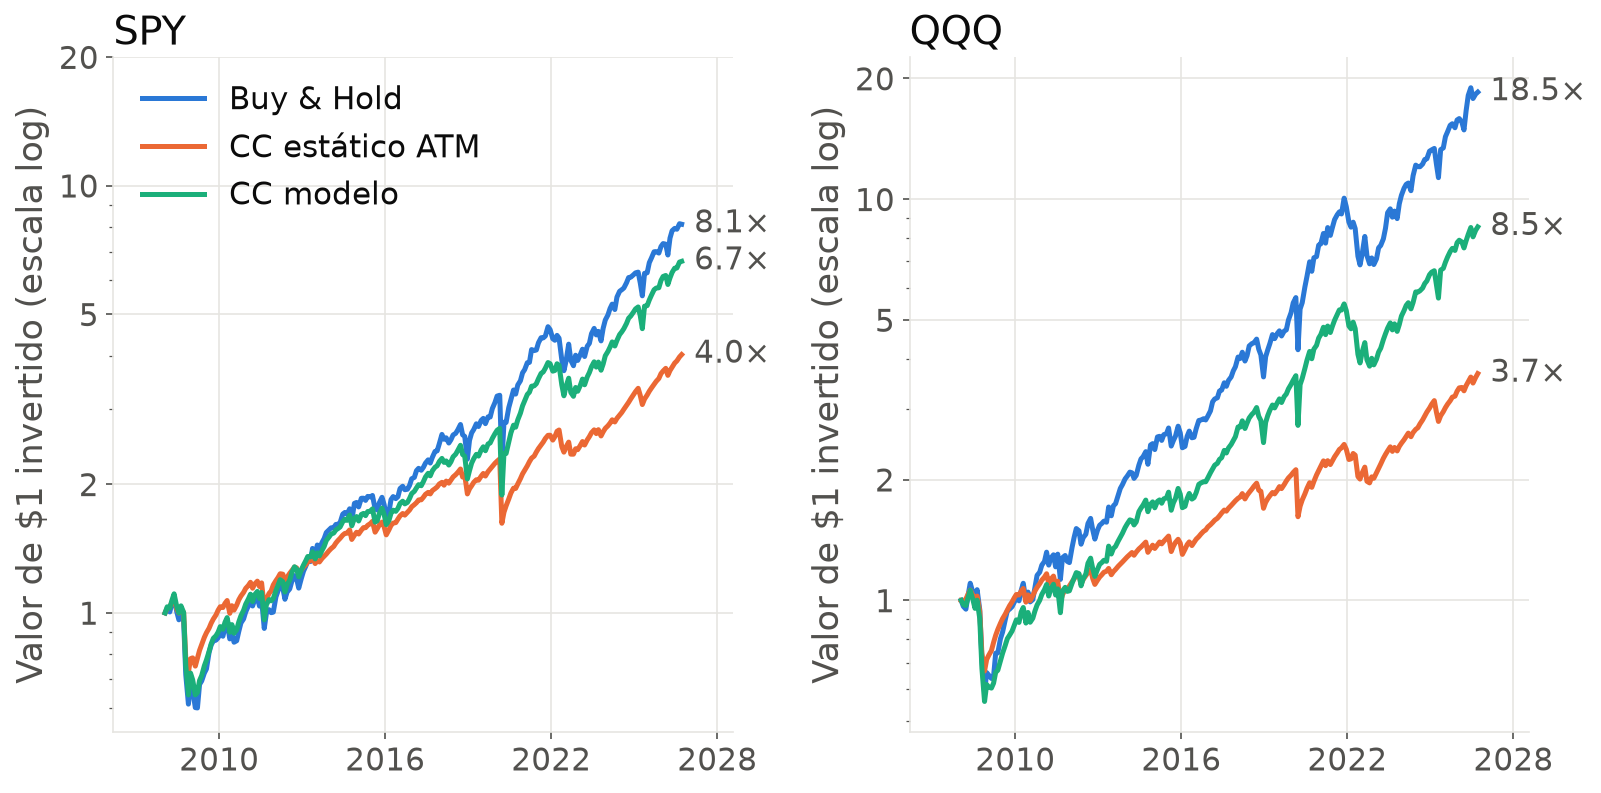

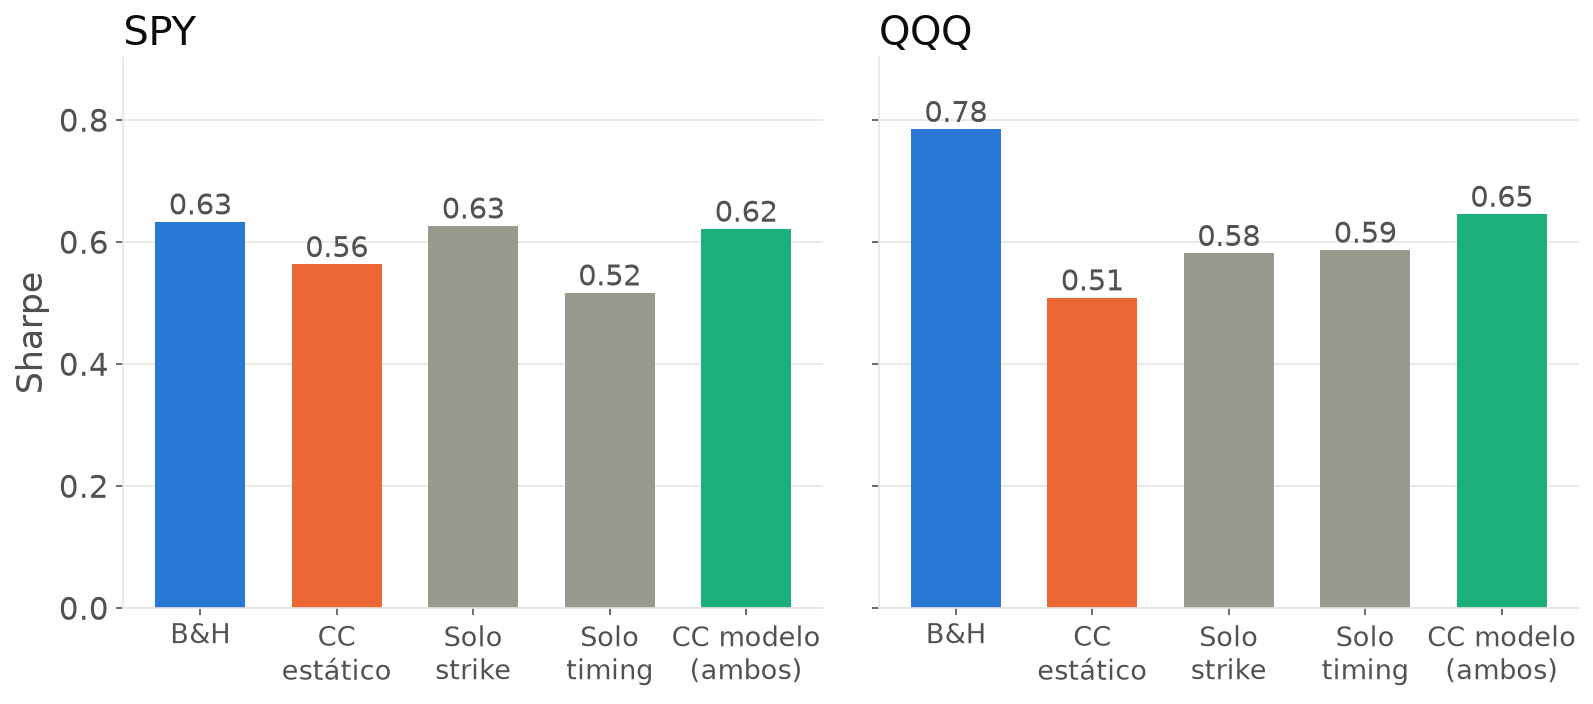

In [8]:
for n in ["fig_signal", "fig_equity", "fig_ablation"]: display(Image(str(FIG / f"{n}.png"), width=620))

### Inferencia: ¿la diferencia es distinguible del azar?
Bootstrap estacionario (bloques de 3 ciclos) sobre la diferencia de retorno por ciclo, anualizada. `p_neg` = fracción de réplicas con media ≤ 0.

In [9]:
for k in boot:
    print(k, "(CC modelo menos la comparación)")
    display(pd.DataFrame(boot[k]).T)
print({k: {a: round(b, 3) for a, b in v.items()} for k, v in extra.items()})

SPY (CC modelo menos la comparación)


,media_anual,lo,hi,p_neg
vs_estatico,0.0332,0.0051,0.0640,0.0110
vs_bh,-0.0141,-0.0338,0.0050,0.9246


QQQ (CC modelo menos la comparación)


,media_anual,lo,hi,p_neg
vs_estatico,0.0543,0.0176,0.0935,0.0028
vs_bh,-0.0473,-0.0720,-0.0234,1.0000


{'SPY': {'psr_modelo': 0.993, 'hit_sell': 0.672, 'hit_nosell_estatico_pierde': 0.457, 'gana_estatico_en_vendidos': 0.003, 'gana_estatico_en_no_vendidos': 0.004}, 'QQQ': {'psr_modelo': 0.997, 'hit_sell': 0.608, 'hit_nosell_estatico_pierde': 0.552, 'gana_estatico_en_vendidos': 0.002, 'gana_estatico_en_no_vendidos': 0.011}}


## 5. Sensibilidades (solo notebook; **ojo: es multiple testing** — el póster usa los valores fijados de antemano z=0.5, m=0, costo=2%)

In [10]:
cyc = {k: build_cycles(A[k]["px"].index) for k in A}
rows = []
for k in A:
    for z in [0, .25, .5, 1]:
        for m in [0, .05, .10]:
            d = ST.simulate(A[k], fcs[k], ST.standard_specs(z=z, m=m)["CC modelo"], cyc[k]); mt = ST.metrics(d)
            rows.append(dict(activo=k, z=z, m=m, CAGR=mt["CAGR"], sharpe=mt["sharpe"], maxdd=mt["maxdd"], pct_vendido=mt["pct_vendido"]))
sens = pd.DataFrame(rows)
for k in A:
    print(k, "— Sharpe por (z, m)"); display(sens[sens.activo == k].pivot(index="z", columns="m", values="sharpe"))

SPY — Sharpe por (z, m)


m,0.0000,0.0500,0.1000
z,,,
0.0000,0.5166,0.5496,0.6487
0.2500,0.5787,0.5975,0.6729
0.5000,0.6212,0.6287,0.6813
1.0000,0.6402,0.6428,0.6535


QQQ — Sharpe por (z, m)


m,0.0000,0.0500,0.1000
z,,,
0.0000,0.5867,0.5986,0.5791
0.2500,0.6186,0.6421,0.6260
0.5000,0.6455,0.6753,0.6682
1.0000,0.7345,0.7414,0.7430


In [11]:
rows = []
for k in A:
    for cost in [0, .02, .05]:
        for skew in [True, False]:
            d = ST.simulate(A[k], fcs[k], ST.standard_specs(cost=cost, skew=skew)["CC modelo"], cyc[k])
            e = ST.simulate(A[k], fcs[k], ST.standard_specs(cost=cost, skew=skew)["CC estático ATM"], cyc[k])
            rows.append(dict(activo=k, costo=cost, skew_IBKR=skew, CAGR_modelo=ST.metrics(d)["CAGR"], CAGR_estatico=ST.metrics(e)["CAGR"]))
pd.DataFrame(rows)

,activo,costo,skew_IBKR,CAGR_modelo,CAGR_estatico
0,SPY,0.0000,True,0.1085,0.0825
1,SPY,0.0000,False,0.1608,0.1181
2,SPY,0.0200,True,0.1068,0.0774
3,SPY,0.0200,False,0.1580,0.1121
4,SPY,0.0500,True,0.1043,0.0699
5,SPY,0.0500,False,0.1538,0.1032
6,QQQ,0.0000,True,0.1234,0.0781
7,QQQ,0.0000,False,0.1824,0.1185
8,QQQ,0.0200,True,0.1217,0.0722
9,QQQ,0.0200,False,0.1793,0.1116


### Una estrategia por modelo de volatilidad (mismo timing + strike, distinto σ̂)

In [12]:
rows = []
for k in A:
    for m in VM.MODELS + ["Ensamble"]:
        d = ST.simulate(A[k], fcs[k], ST.standard_specs(sigma=m)["CC modelo"], cyc[k]); mt = ST.metrics(d)
        rows.append(dict(activo=k, sigma=m, CAGR=mt["CAGR"], sharpe=mt["sharpe"], maxdd=mt["maxdd"], pct_vendido=mt["pct_vendido"]))
pd.DataFrame(rows).pivot(index="sigma", columns="activo", values=["CAGR", "sharpe", "pct_vendido"])

CAGR        sharpe        pct_vendido       
activo       QQQ    SPY    QQQ    SPY         QQQ    SPY
sigma                                                   
EWMA      0.1168 0.1081 0.6243 0.6290      0.7946 0.8616
Ensamble  0.1217 0.1068 0.6455 0.6212      0.7411 0.8438
GJR-GARCH 0.1202 0.1121 0.6351 0.6456      0.6964 0.7857
HAR-RV    0.1169 0.1040 0.6437 0.6184      0.5982 0.6071
Kalman    0.1141 0.1133 0.6335 0.6559      0.7321 0.7589
Rolling21 0.1219 0.1108 0.6476 0.6426      0.7768 0.8348

## 6. Chequeos de cordura

In [13]:
print("Sin look-ahead (|Δ| tras corromper el futuro):", CK.check_no_lookahead(A["SPY"]))
print("Estático == 'siempre + z=0' (max |Δret|):", CK.check_static_equals_z0(A["SPY"], fcs["SPY"]))
bw = CK.check_vs_buywrite(A["SPY"], fcs["SPY"])
print(f"CC estático simulado vs ETF BuyWrite real (PBP): corr mensual {bw.attrs['corr']:.3f} | CAGR {bw.attrs['cagr_sim']:.2%} vs {bw.attrs['cagr_pbp']:.2%} (PBP cobra ~0.75% anual)")
bh = res["SPY"]["Buy & Hold"]; adj = A["SPY"]["px"]["Adj Close"]
print("B&H por ciclos vs Adj Close:", round((1 + bh.ret).prod() - 1, 4), round(adj.loc[bh.texp.iloc[-1]] / adj.loc[bh.index[0]] - 1, 4))

Sin look-ahead (|Δ| tras corromper el futuro): {'Rolling21': 0.0, 'EWMA': 0.0, 'GJR-GARCH': 0.0, 'HAR-RV': 0.0, 'Kalman': 0.0, 'Ensamble': 0.0, 'IV_sig': 0.0}


Estático == 'siempre + z=0' (max |Δret|): 0.0


CC estático simulado vs ETF BuyWrite real (PBP): corr mensual 0.972 | CAGR 7.74% vs 5.85% (PBP cobra ~0.75% anual)
B&H por ciclos vs Adj Close: 7.1235 7.1178


## 7. Interpretación (provisoria — para discutir)
- **Contra el CC estático, el modelo gana** en ambos activos, con IC95% (bootstrap) que excluye 0.
- **Contra Buy & Hold, el CC modelo no gana en retorno** (SPY: el IC95% de la diferencia incluye 0; QQQ: pierde claramente), pero reduce volatilidad y drawdown. Hay un costo estructural: el techo al upside en el mercado alcista 2009-2026.
- **Ablación (timing vs strike):** en SPY el timing solo (σ̂<IV con strike ATM) *no* mejora al CC estático (Sharpe 0.52 vs 0.56); la mejora viene de fijar el strike con σ̂ (0.63). En QQQ el timing sí suma (0.65 con ambos vs 0.58 solo strike).
- **Los modelos sofisticados casi no se distinguen en la estrategia:** corriendo la misma regla con cada σ̂, los Sharpe quedan entre 0.62 y 0.66 (SPY) y 0.62 y 0.65 (QQQ); incluso el rolling ingenuo rinde parecido al ensamble. Mejor pronóstico (QLIKE) no se traduce en mucho mejor P&L.
- **El skew importa muchísimo:** con IV plana (sin ajuste IBKR) el CC estático parecería igualar al B&H (CAGR 11.2% vs 11.9% en SPY), un resultado irreal; con el skew calibrado el CC estático replica al ETF BuyWrite real (corr. 0.97).
- **Heterogeneidad por activo:** el efecto del *upside capping* pesa mucho más en QQQ por su mayor crecimiento.
- **Limitaciones:** IV del índice (no de la opción exacta), skew calibrado en un único régimen, precios BS (no bid/ask real), costos supuestos, dos activos, NVDA excluido.